In [1]:
from xgboost import XGBClassifier

print("XGBoost imported successfully!")

XGBoost imported successfully!


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
import os

processed_path = "../data/processed"

print("Files in data/processed:")
for file in sorted(os.listdir(processed_path)):
    print(file)

Files in data/processed:
isolation_forest_results.csv
leakmind_features.csv
leakmind_features_with_anomaly.csv
r1_weekly_normal_features.csv
r42_1_parsed_events.csv
r42_all_parsed_events.csv
r42_all_scenario_features.csv


In [8]:
import pandas as pd

normal = pd.read_csv(
    "../data/processed/r1_weekly_normal_features.csv"
)

insider = pd.read_csv(
    "../data/processed/r42_all_scenario_features.csv"
)

print("Normal shape:", normal.shape)
print("Normal columns:")
print(normal.columns.tolist())

print("\nInsider shape:", insider.shape)
print("Insider columns:")
print(insider.columns.tolist())

Normal shape: (68762, 15)
Normal columns:
['user', 'week', 'http_activity_count', 'after_hours_activity', 'total_logon_events', 'unique_pcs', 'logon_count', 'logoff_count', 'after_hours_logon', 'total_device_events', 'device_pcs', 'device_connect_count', 'device_disconnect_count', 'after_hours_device', 'normal_label']

Insider shape: (80, 17)
Insider columns:
['scenario', 'user', 'scenario_start', 'scenario_end', 'total_events', 'logon_count', 'logoff_count', 'device_connect_count', 'device_disconnect_count', 'http_count', 'after_hours_events', 'after_hours_logon', 'after_hours_http', 'wikileaks_access', 'unique_pcs', 'scenario_duration_hours', 'insider_label']


In [11]:
import pandas as pd

normal = pd.read_csv(
    "../data/processed/r1_weekly_normal_features.csv"
)

insider = pd.read_csv(
    "../data/processed/r42_all_scenario_features.csv"
)

print("Normal shape:", normal.shape)
print("Insider shape:", insider.shape)

Normal shape: (68762, 15)
Insider shape: (80, 17)


In [14]:
# Create the supervised dataset

import pandas as pd

# Load the datasets
normal = pd.read_csv(
    "../data/processed/r1_weekly_normal_features.csv"
)

insider = pd.read_csv(
    "../data/processed/r42_all_scenario_features.csv"
)

# -----------------------------
# 1. Normal samples
# -----------------------------
normal_sample = normal.sample(
    n=700,
    random_state=42
).copy()

normal_sample["insider_label"] = 0

# -----------------------------
# 2. Insider samples
# -----------------------------
insider_sample = insider.copy()

insider_sample = insider_sample.rename(columns={
    "http_count": "http_activity_count",
    "after_hours_http": "after_hours_activity"
})

insider_sample["total_device_events"] = (
    insider_sample["device_connect_count"] +
    insider_sample["device_disconnect_count"]
)

insider_sample["insider_label"] = 1

# -----------------------------
# 3. Common features
# -----------------------------
common_features = [
    "http_activity_count",
    "after_hours_activity",
    "logon_count",
    "logoff_count",
    "after_hours_logon",
    "unique_pcs",
    "device_connect_count",
    "device_disconnect_count",
    "total_device_events"
]

# -----------------------------
# 4. Create X
# -----------------------------
X_normal = normal_sample[common_features]
X_insider = insider_sample[common_features]

X = pd.concat(
    [X_normal, X_insider],
    ignore_index=True
)

# -----------------------------
# 5. Create y
# -----------------------------
y = pd.concat(
    [
        normal_sample["insider_label"],
        insider_sample["insider_label"]
    ],
    ignore_index=True
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts())

X shape: (780, 9)
y shape: (780,)

Class distribution:
insider_label
0    700
1     80
Name: count, dtype: int64


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())

X_train: (624, 9)
X_test: (156, 9)

y_train distribution:
insider_label
0    560
1     64
Name: count, dtype: int64

y_test distribution:
insider_label
0    140
1     16
Name: count, dtype: int64


Train/Test Split

In [16]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

print("All three models trained successfully!")

All three models trained successfully!


In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0,1.0,1.0
2,XGBoost,1.0,1.0,1.0,1.0,1.0,1.0


In [18]:
from sklearn.metrics import confusion_matrix, classification_report

for name, model in models.items():

    y_pred = model.predict(X_test)

    print("=" * 60)
    print(name)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Insider"],
        zero_division=0
    ))

Logistic Regression

Confusion Matrix:
[[140   0]
 [  0  16]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       140
     Insider       1.00      1.00      1.00        16

    accuracy                           1.00       156
   macro avg       1.00      1.00      1.00       156
weighted avg       1.00      1.00      1.00       156

Random Forest

Confusion Matrix:
[[140   0]
 [  0  16]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       140
     Insider       1.00      1.00      1.00        16

    accuracy                           1.00       156
   macro avg       1.00      1.00      1.00       156
weighted avg       1.00      1.00      1.00       156

XGBoost

Confusion Matrix:
[[140   0]
 [  0  16]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       1

In [19]:
# Compare average feature values between normal and insider classes

comparison = X.copy()
comparison["label"] = y.values

feature_comparison = comparison.groupby("label")[common_features].mean().T

feature_comparison.columns = ["Normal", "Insider"]

feature_comparison["Difference"] = (
    feature_comparison["Insider"] -
    feature_comparison["Normal"]
)

feature_comparison

,Normal,Insider,Difference
http_activity_count,55.641429,48.2500,-7.391429
after_hours_activity,1.188571,1.4000,0.211429
logon_count,7.038571,1.2375,-5.801071
logoff_count,5.684286,1.2375,-4.446786
after_hours_logon,1.487143,1.0000,-0.487143
unique_pcs,1.782857,1.7375,-0.045357
device_connect_count,0.492857,17.4250,16.932143
device_disconnect_count,0.444286,17.3875,16.943214
total_device_events,0.937143,34.8125,33.875357


In [20]:
for feature in common_features:

    print("=" * 60)
    print(feature)

    print("Normal:")
    print(X.loc[y == 0, feature].describe())

    print("\nInsider:")
    print(X.loc[y == 1, feature].describe())

http_activity_count
Normal:
count     700.000000
mean       55.641429
std       128.992969
min         0.000000
25%         4.000000
50%        11.000000
75%        43.000000
max      1186.000000
Name: http_activity_count, dtype: float64

Insider:
count     80.000000
mean      48.250000
std       59.983437
min        0.000000
25%        2.000000
50%        3.000000
75%      120.000000
max      149.000000
Name: http_activity_count, dtype: float64
after_hours_activity
Normal:
count    700.000000
mean       1.188571
std        8.552715
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      111.000000
Name: after_hours_activity, dtype: float64

Insider:
count    80.000000
mean      1.400000
std       3.196517
min       0.000000
25%       0.000000
50%       0.000000
75%       2.000000
max      21.000000
Name: after_hours_activity, dtype: float64
logon_count
Normal:
count    700.000000
mean       7.038571
std        4.677582
min        3.000000
25%        5.

In [21]:
print("Total insider rows:", len(insider))

print(
    "Unique scenarios:",
    insider["scenario"].nunique()
)

print(
    "Duplicate scenario rows:",
    insider["scenario"].duplicated().sum()
)

print("\nScenario counts:")
print(
    insider["scenario"]
    .value_counts()
    .head(20)
)

Total insider rows: 80
Unique scenarios: 70
Duplicate scenario rows: 10

Scenario counts:
scenario
r4.2-3-BBS0039    2
r4.2-3-BSS0369    2
r4.2-3-CCA0046    2
r4.2-3-CSC0217    2
r4.2-3-GTD0219    2
r4.2-3-JGT0221    2
r4.2-3-JLM0364    2
r4.2-3-JTM0223    2
r4.2-3-MPM0220    2
r4.2-3-MSO0222    2
r4.2-1-AAM0658    1
r4.2-1-AJR0932    1
r4.2-1-BDV0168    1
r4.2-1-BIH0745    1
r4.2-1-BLS0678    1
r4.2-1-BTL0226    1
r4.2-1-CAH0936    1
r4.2-1-DCH0843    1
r4.2-1-EHB0824    1
r4.2-1-EHD0584    1
Name: count, dtype: int64


In [22]:
# Keep only one feature row per insider scenario

insider_clean = (
    insider
    .drop_duplicates(subset="scenario", keep="first")
    .copy()
)

print("Original insider rows:", len(insider))
print("Clean insider rows:", len(insider_clean))
print("Unique scenarios:", insider_clean["scenario"].nunique())

print("\nDuplicate scenarios remaining:")
print(insider_clean["scenario"].duplicated().sum())

Original insider rows: 80
Clean insider rows: 70
Unique scenarios: 70

Duplicate scenarios remaining:
0


In [23]:
# -----------------------------
# Normal data
# -----------------------------

normal_sample = normal.sample(
    n=700,
    random_state=42
).copy()

normal_sample["insider_label"] = 0


# -----------------------------
# Clean insider data
# -----------------------------

insider_sample = insider_clean.copy()

insider_sample = insider_sample.rename(columns={
    "http_count": "http_activity_count",
    "after_hours_http": "after_hours_activity"
})

insider_sample["total_device_events"] = (
    insider_sample["device_connect_count"] +
    insider_sample["device_disconnect_count"]
)

insider_sample["insider_label"] = 1


# -----------------------------
# Common features
# -----------------------------

common_features = [
    "http_activity_count",
    "after_hours_activity",
    "logon_count",
    "logoff_count",
    "after_hours_logon",
    "unique_pcs",
    "device_connect_count",
    "device_disconnect_count",
    "total_device_events"
]


# -----------------------------
# Create X and y
# -----------------------------

X_normal = normal_sample[common_features].copy()
X_insider = insider_sample[common_features].copy()

X = pd.concat(
    [X_normal, X_insider],
    ignore_index=True
)

y = pd.concat(
    [
        normal_sample["insider_label"],
        insider_sample["insider_label"]
    ],
    ignore_index=True
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts())

X shape: (770, 9)
y shape: (770,)

Class distribution:
insider_label
0    700
1     70
Name: count, dtype: int64


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())

X_train: (616, 9)
X_test: (154, 9)

y_train distribution:
insider_label
0    560
1     56
Name: count, dtype: int64

y_test distribution:
insider_label
0    140
1     14
Name: count, dtype: int64


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

# Train
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

print("All three models retrained successfully on the clean dataset!")

All three models retrained successfully on the clean dataset!


In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0,1.0,1.0
2,XGBoost,1.0,1.0,1.0,1.0,1.0,1.0


In [1]:
import pandas as pd

X_daily = pd.read_csv(
    "../data/processed/X_daily_supervised.csv"
)

y_daily = pd.read_csv(
    "../data/processed/y_daily_supervised.csv"
).squeeze()

print("X_daily shape:", X_daily.shape)
print("y_daily shape:", y_daily.shape)

print("\nClass distribution:")
print(y_daily.value_counts())

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/X_daily_supervised.csv'

In [2]:
# ==========================================
# Load Daily Supervised Dataset
# ==========================================

import pandas as pd
import numpy as np

X_daily = pd.read_csv(
    "../data/processed/X_daily_supervised.csv"
)

y_daily = pd.read_csv(
    "../data/processed/y_daily_supervised.csv"
).squeeze()

print("===================================")
print("Daily supervised dataset loaded")
print("===================================")

print("X_daily shape:", X_daily.shape)
print("y_daily shape:", y_daily.shape)

print("\nClass distribution:")
print(y_daily.value_counts())

print("\nFeature columns:")
print(X_daily.columns.tolist())

Daily supervised dataset loaded
X_daily shape: (140, 9)
y_daily shape: (140,)

Class distribution:
insider_label
0    70
1    70
Name: count, dtype: int64

Feature columns:
['http_activity_count', 'after_hours_activity', 'logon_count', 'logoff_count', 'after_hours_logon', 'unique_pcs', 'device_connect_count', 'device_disconnect_count', 'total_device_events']


In [3]:
# ==========================================
# Create Train/Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_daily,
    y_daily,
    test_size=0.20,
    random_state=42,
    stratify=y_daily
)

print("===================================")
print("Train/Test Split")
print("===================================")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())

Train/Test Split
X_train: (112, 9)
X_test : (28, 9)

y_train distribution:
insider_label
0    56
1    56
Name: count, dtype: int64

y_test distribution:
insider_label
1    14
0    14
Name: count, dtype: int64


In [4]:
# ==========================================
# Train Logistic Regression, Random Forest
# and XGBoost
# ==========================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ------------------------------------------
# 1. Scale data for Logistic Regression
# ------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------
# 2. Logistic Regression
# ------------------------------------------

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

# ------------------------------------------
# 3. Random Forest
# ------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

# ------------------------------------------
# 4. XGBoost
# ------------------------------------------

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train,
    y_train
)

print("===================================")
print("All three models trained")
print("===================================")
print("Logistic Regression: trained")
print("Random Forest      : trained")
print("XGBoost            : trained")

All three models trained
Logistic Regression: trained
Random Forest      : trained
XGBoost            : trained


Evaluate Daily Models

In [5]:
# ==========================================
# Evaluate Daily Models
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Logistic Regression": (
        logistic_model,
        X_test_scaled
    ),
    "Random Forest": (
        rf_model,
        X_test
    ),
    "XGBoost": (
        xgb_model,
        X_test
    )
}

results = []

for name, (model, X_eval) in models.items():

    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

print("===================================")
print("Daily Model Comparison")
print("===================================")

display(
    results_df.round(4)
)

Daily Model Comparison


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0,1.0
2,XGBoost,1.0,1.0,1.0,1.0,1.0


In [7]:
# ==========================================
# Compare Normal vs Insider Feature Means
# ==========================================

# The first 70 rows are normal
# The next 70 rows are insider

X_normal_daily = X_daily.iloc[:70].copy()
X_insider_daily = X_daily.iloc[70:].copy()

comparison = pd.DataFrame({
    "Normal Mean": X_normal_daily.mean(),
    "Insider Mean": X_insider_daily.mean()
})

comparison["Difference"] = (
    comparison["Insider Mean"] -
    comparison["Normal Mean"]
)

comparison["Ratio"] = (
    comparison["Insider Mean"] /
    comparison["Normal Mean"].replace(0, np.nan)
)

print("===================================")
print("Normal vs Insider Feature Comparison")
print("===================================")

display(comparison.round(3))

Normal vs Insider Feature Comparison


,Normal Mean,Insider Mean,Difference,Ratio
http_activity_count,9.786,3.500,-6.286,0.358
after_hours_activity,0.043,0.400,0.357,9.333
logon_count,1.343,0.571,-0.771,0.426
logoff_count,1.129,0.486,-0.643,0.430
after_hours_logon,0.257,0.486,0.229,1.889
unique_pcs,1.129,1.143,0.014,1.013
device_connect_count,0.100,0.714,0.614,7.143
device_disconnect_count,0.100,0.714,0.614,7.143
total_device_events,0.200,1.429,1.229,7.143


In [8]:
# ==========================================
# XGBoost Confusion Matrix
# ==========================================

from sklearn.metrics import confusion_matrix, classification_report

y_pred_xgb = xgb_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

print("===================================")
print("XGBoost Confusion Matrix")
print("===================================")

print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=["Normal", "Insider"]
    )
)

XGBoost Confusion Matrix
[[14  0]
 [ 0 14]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        14
     Insider       1.00      1.00      1.00        14

    accuracy                           1.00        28
   macro avg       1.00      1.00      1.00        28
weighted avg       1.00      1.00      1.00        28



In [9]:
# ==========================================
# XGBoost Feature Importance
# ==========================================

feature_importance = pd.DataFrame({
    "Feature": X_daily.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("===================================")
print("XGBoost Feature Importance")
print("===================================")

display(
    feature_importance.round(4)
)

XGBoost Feature Importance


,Feature,Importance
0,logoff_count,0.2510
1,total_device_events,0.2132
2,logon_count,0.1859
3,device_connect_count,0.1544
4,device_disconnect_count,0.1001
5,http_activity_count,0.0364
6,after_hours_activity,0.0248
7,unique_pcs,0.0176
8,after_hours_logon,0.0167


In [11]:
# ==========================================
# SHAP Explanation for XGBoost
# ==========================================

import shap
import matplotlib.pyplot as plt

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

print("===================================")
print("SHAP values calculated")
print("===================================")

print("SHAP shape:", shap_values.shape)
print("Test data shape:", X_test.shape)

c:\Users\USER\OneDrive\Desktop\leakmind project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values calculated
SHAP shape: (28, 9)
Test data shape: (28, 9)


In [12]:
import shap

print("SHAP version:", shap.__version__)
print("SHAP installed successfully.")

SHAP version: 0.52.0
SHAP installed successfully.


In [13]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

print("===================================")
print("SHAP values calculated")
print("===================================")

print("SHAP shape:", shap_values.shape)
print("Test data shape:", X_test.shape)

SHAP values calculated
SHAP shape: (28, 9)
Test data shape: (28, 9)


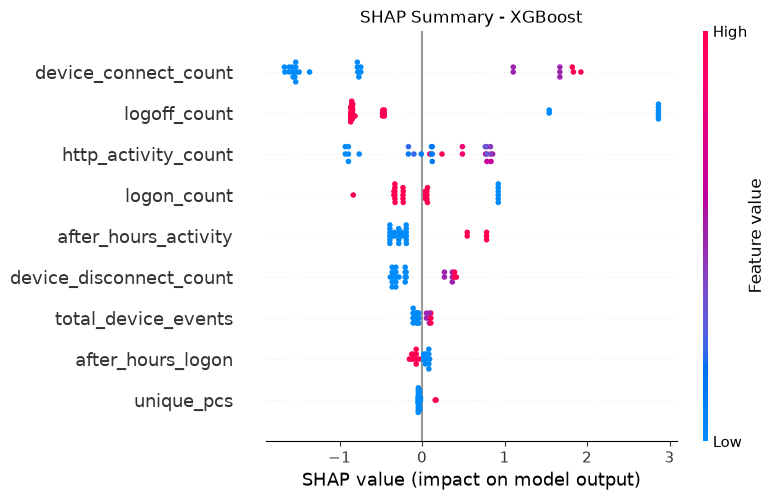

In [14]:
# ==========================================
# SHAP Summary Plot
# ==========================================

plt.figure()

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title("SHAP Summary - XGBoost")
plt.tight_layout()
plt.show()

In [15]:
# ==========================================
# Generate Leakage Risk Scores
# ==========================================

# Probability of insider class
risk_probability = xgb_model.predict_proba(X_test)[:, 1]

# Convert to percentage
risk_score = risk_probability * 100

risk_results = X_test.copy()

risk_results["actual_label"] = y_test.values
risk_results["risk_probability"] = risk_probability
risk_results["risk_score"] = risk_score

# Model prediction
risk_results["predicted_label"] = (
    xgb_model.predict(X_test)
)

print("===================================")
print("Leakage Risk Scores")
print("===================================")

display(
    risk_results[
        [
            "risk_probability",
            "risk_score",
            "actual_label",
            "predicted_label"
        ]
    ].head(10).round(4)
)

Leakage Risk Scores


,risk_probability,risk_score,actual_label,predicted_label
93,0.9722,97.219398,1,1
95,0.9722,97.219398,1,1
51,0.0173,1.726900,0,0
137,0.9291,92.912498,1,1
21,0.0599,5.992200,0,0
94,0.9249,92.492401,1,1
1,0.0327,3.273400,0,0
43,0.0199,1.991100,0,0
23,0.0250,2.503200,0,0
98,0.9249,92.492401,1,1


In [17]:
# Reconstruct the same 70 normal + 70 insider ordering
# used to create X_daily

# Load the saved daily normal dataset
daily_normal = pd.read_csv(
    "../data/processed/r1_daily_normal_features.csv"
)

# Load the saved daily insider dataset
daily_insider = pd.read_csv(
    "../data/processed/r42_all_parsed_events.csv"
)

# ---------------------------------------------------------
# Recreate 70 normal samples
# ---------------------------------------------------------

daily_normal_sample = daily_normal.sample(
    n=70,
    random_state=42
).copy()

daily_normal_sample["insider_label"] = 0

normal_info = daily_normal_sample[
    ["user", "day"]
].reset_index(drop=True)


# ---------------------------------------------------------
# Recreate daily insider features
# ---------------------------------------------------------

daily_insider["timestamp"] = pd.to_datetime(
    daily_insider["timestamp"],
    errors="coerce"
)

daily_insider["day"] = daily_insider["timestamp"].dt.date

daily_insider["is_http"] = (
    daily_insider["event_type"] == "http"
).astype(int)

daily_insider["is_logon"] = (
    (daily_insider["event_type"] == "logon") &
    (daily_insider["action"] == "Logon")
).astype(int)

daily_insider["is_logoff"] = (
    (daily_insider["event_type"] == "logon") &
    (daily_insider["action"] == "Logoff")
).astype(int)

daily_insider["is_connect"] = (
    (daily_insider["event_type"] == "device") &
    (daily_insider["action"] == "Connect")
).astype(int)

daily_insider["is_disconnect"] = (
    (daily_insider["event_type"] == "device") &
    (daily_insider["action"] == "Disconnect")
).astype(int)

daily_insider["hour"] = daily_insider["timestamp"].dt.hour

daily_insider["after_hours"] = (
    (daily_insider["hour"] < 7) |
    (daily_insider["hour"] >= 19)
).astype(int)

daily_insider["after_hours_logon_event"] = (
    (daily_insider["is_logon"] == 1) &
    (daily_insider["after_hours"] == 1)
).astype(int)

daily_insider["after_hours_http_event"] = (
    (daily_insider["is_http"] == 1) &
    (daily_insider["after_hours"] == 1)
).astype(int)


daily_insider_features = daily_insider.groupby(
    ["scenario", "user", "day"]
).agg(
    http_activity_count=("is_http", "sum"),
    after_hours_activity=("after_hours_http_event", "sum"),
    logon_count=("is_logon", "sum"),
    logoff_count=("is_logoff", "sum"),
    after_hours_logon=("after_hours_logon_event", "sum"),
    unique_pcs=("pc", "nunique"),
    device_connect_count=("is_connect", "sum"),
    device_disconnect_count=("is_disconnect", "sum")
).reset_index()

daily_insider_features["total_device_events"] = (
    daily_insider_features["device_connect_count"] +
    daily_insider_features["device_disconnect_count"]
)


# ---------------------------------------------------------
# Select exactly one day per insider scenario
# Same ordering as before
# ---------------------------------------------------------

daily_insider_sample = (
    daily_insider_features
    .sort_values(["scenario", "day"])
    .drop_duplicates(
        subset="scenario",
        keep="first"
    )
    .copy()
)

insider_info = daily_insider_sample[
    ["scenario", "user", "day"]
].reset_index(drop=True)


# ---------------------------------------------------------
# Combine identifiers in exactly the same order as X_daily
# ---------------------------------------------------------

risk_info = pd.concat(
    [
        normal_info.assign(scenario="NORMAL"),
        insider_info
    ],
    ignore_index=True
)


# ---------------------------------------------------------
# Get identifiers for the X_test rows
# ---------------------------------------------------------

test_indices = X_test.index

risk_info_test = risk_info.loc[
    test_indices
].reset_index(drop=True)


print("Risk identifier reconstruction successful.")
print("Total rows:", len(risk_info))
print("Test rows:", len(risk_info_test))

display(risk_info_test.head(10))

Risk identifier reconstruction successful.
Total rows: 140
Test rows: 28


,user,day,scenario
0,MYD0978,2010-12-13,r4.2-1-MYD0978
1,RAB0589,2010-09-13,r4.2-1-RAB0589
2,DTAA/ASS0824,2010-05-17,NORMAL
3,JTM0223,2010-07-22,r4.2-3-JTM0223
4,DTAA/MGB0728,2011-02-08,NORMAL
5,PPF0435,2011-02-09,r4.2-1-PPF0435
6,DTAA/IAC0264,2011-03-11,NORMAL
7,DTAA/EAM0745,2010-10-22,NORMAL
8,DTAA/KIM0617,2010-11-19,NORMAL
9,TAP0551,2010-10-23,r4.2-1-TAP0551


In [18]:
risk_probability = xgb_model.predict_proba(X_test)[:, 1]
risk_score = risk_probability * 100

risk_results = risk_info_test.copy()

risk_results["risk_probability"] = risk_probability
risk_results["risk_score"] = risk_score

risk_results["actual_label"] = y_test.values
risk_results["predicted_label"] = xgb_model.predict(X_test)

risk_results = risk_results.sort_values(
    "risk_score",
    ascending=False
).reset_index(drop=True)

display(risk_results.head(15))

,user,day,scenario,risk_probability,risk_score,actual_label,predicted_label
0,MYD0978,2010-12-13,r4.2-1-MYD0978,0.972194,97.219429,1,1
1,RAB0589,2010-09-13,r4.2-1-RAB0589,0.972194,97.219429,1,1
2,PNL0301,2010-06-14,r4.2-2-PNL0301,0.968167,96.816742,1,1
3,EGD0132,2010-08-02,r4.2-2-EGD0132,0.967669,96.766945,1,1
4,FSC0601,2011-01-18,r4.2-2-FSC0601,0.967395,96.739464,1,1
5,XHW0498,2010-08-09,r4.2-2-XHW0498,0.967395,96.739464,1,1
6,KRL0501,2010-11-22,r4.2-2-KRL0501,0.956005,95.600449,1,1
7,IKR0401,2010-12-27,r4.2-2-IKR0401,0.956005,95.600449,1,1
8,JTM0223,2010-07-22,r4.2-3-JTM0223,0.929125,92.912529,1,1
9,BBS0039,2010-08-12,r4.2-3-BBS0039,0.925645,92.564453,1,1


In [19]:
# ============================================
# LeakMind Policy Engine
# ============================================

def apply_policy(risk_score):

    if risk_score < 40:
        return "ALLOW"

    elif risk_score < 70:
        return "MONITOR"

    elif risk_score <= 90:
        return "ALERT + APPROVAL"

    else:
        return "BLOCK"


# Apply policy to every test sample
risk_results["policy_action"] = (
    risk_results["risk_score"]
    .apply(apply_policy)
)

display(
    risk_results[
        [
            "user",
            "day",
            "scenario",
            "risk_score",
            "actual_label",
            "predicted_label",
            "policy_action"
        ]
    ].head(20)
)

,user,day,scenario,risk_score,actual_label,predicted_label,policy_action
0,MYD0978,2010-12-13,r4.2-1-MYD0978,97.219429,1,1,BLOCK
1,RAB0589,2010-09-13,r4.2-1-RAB0589,97.219429,1,1,BLOCK
2,PNL0301,2010-06-14,r4.2-2-PNL0301,96.816742,1,1,BLOCK
3,EGD0132,2010-08-02,r4.2-2-EGD0132,96.766945,1,1,BLOCK
4,FSC0601,2011-01-18,r4.2-2-FSC0601,96.739464,1,1,BLOCK
5,XHW0498,2010-08-09,r4.2-2-XHW0498,96.739464,1,1,BLOCK
6,KRL0501,2010-11-22,r4.2-2-KRL0501,95.600449,1,1,BLOCK
7,IKR0401,2010-12-27,r4.2-2-IKR0401,95.600449,1,1,BLOCK
8,JTM0223,2010-07-22,r4.2-3-JTM0223,92.912529,1,1,BLOCK
9,BBS0039,2010-08-12,r4.2-3-BBS0039,92.564453,1,1,BLOCK


In [20]:
policy_distribution = (
    risk_results["policy_action"]
    .value_counts()
)

display(policy_distribution)

policy_action
ALLOW               14
BLOCK               13
ALERT + APPROVAL     1
Name: count, dtype: int64

In [21]:
risk_results.to_csv(
    "../data/processed/leakmind_risk_policy_results.csv",
    index=False
)

print(
    "Risk and policy results saved successfully."
)
print(
    "../data/processed/leakmind_risk_policy_results.csv"
)

Risk and policy results saved successfully.
../data/processed/leakmind_risk_policy_results.csv
